<a href="https://colab.research.google.com/github/nishank1225/ML-practice/blob/main/week2_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-n

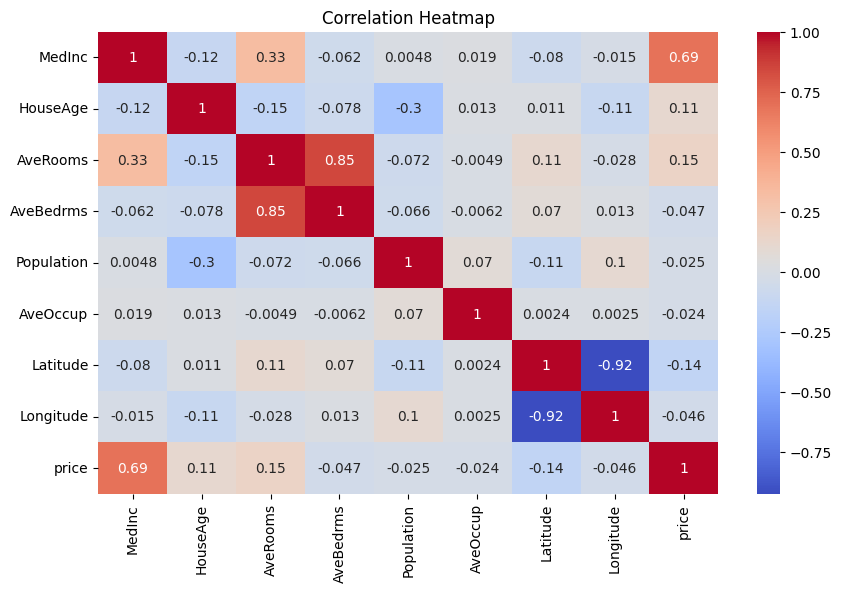

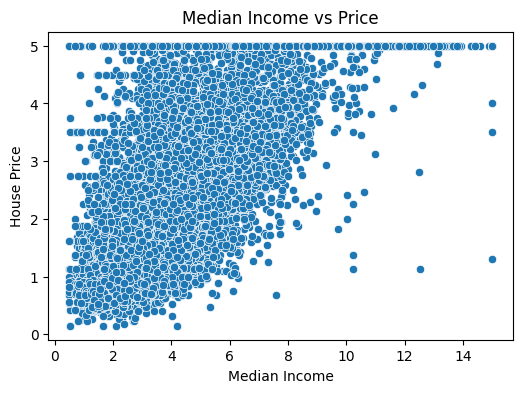


Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)

Model Performance:
MAE: 0.5332001304956553
MSE: 0.5558915986952444
R2 Score: 0.5757877060324508

Feature Importance (Coefficients):
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708

Intercept: -37.02327770606409


In [ ]:
# =====================================
# 📌 STEP 1: Import Libraries
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================
# 📌 STEP 2: Load Dataset
# =====================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['price'] = housing.target

print("First 5 rows:")
print(df.head())

# =====================================
# 📌 STEP 3: EDA (Exploratory Data Analysis)
# =====================================
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='MedInc', y='price', data=df)
plt.title("Median Income vs Price")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.show()

# =====================================
# 📌 STEP 4: Data Preprocessing
# =====================================
X = df.drop('price', axis=1)
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# =====================================
# 📌 STEP 5: Model Training
# =====================================
model = LinearRegression()
model.fit(X_train, y_train)

# =====================================
# 📌 STEP 6: Prediction
# =====================================
y_pred = model.predict(X_test)

# =====================================
# 📌 STEP 7: Model Evaluation
# =====================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

# =====================================
# 📌 STEP 8: Interpretation
# =====================================
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance (Coefficients):")
print(coeff_df)

print("\nIntercept:", model.intercept_)